# The Timeseries Quantum Autoencoder
*TS QAE in Qiskit with angle encoding of TS sliding windows*

By: Jacob Cybulski<br>
Date: August 2023 - March 2024<br>
Aims: The goal of this notebook is to build a Time Series Quantum Autoencoder, 
    a circuit which can compress a quantum state of a timeseries onto a smaller amount of qubits, 
    while retaining the information from the initial state.
Methods: A QAE model from Qiskit Tutorial 12 has been adopted for time series processing. 
- Time series data was converted to a series of sliding windows.
- Several approaches to TS data encoding were tested, i.e. unary, binary and anglular.
- Angle encoding was eventually used, with values centered around H state, in the range of [-pi/2..pi/2]
- The model featuring an input and encoder blocks only (followed by a swap test) was subsequently trained.
- A decoder was then added for testing, and the circuit initialised with an optimum set of parameters from training.
- Each test sample was then encoded into the full QAE circuit, which was executed using a state vector simulation.
- State vectors of input and output data was then visualised and compared. 

Sources: 
1. Romero, Jonathan, Jonathan P. Olson, and Alan Aspuru-Guzik. 2017. “Quantum Autoencoders for Efficient Compression of Quantum Data.” Quantum Science and Technology 2 (4): 045001.
2. Bravo-Prieto, Carlos, "Quantum autoencoders with enhanced data encoding." Machine Learning: Science and Technology, 2, May 2021
3. Qiskit Tutorial, https://qiskit.org/ecosystem/machine-learning/tutorials/12_quantum_autoencoder.html. *Based on [1].*
4. Eugenia Anello, Denoising Autoencoder in Pytorch on MNIST dataset, Dataseries (Medium), Jun 28, 2021.
5. Eugenia Anello, <a href="https://github.com/eugeniaring/Medium-Articles/blob/main/Pytorch/denAE.ipynb">GitHub</a>, Jun 28, 2021.
6. Phillip Lippe, Tutorial 9: Deep Autoencoders, UvA Deep Learning Tutorials, Fall 2022.

Notes:
- Refer to the end of the notebook for the log of changes
- Algorithm by Romera was followed
- Results of the enhanced algorithm by Bravo-Prieto could not be reproduced

## Initial settings

In [1]:
%%html
<style>
table {float:left}
</style>

In [2]:
import sys
sys.path.append('.')
sys.path.append('..')
sys.path.append('../..')
sys.path.append('../../..')
sys.path

['/home/jacob/Dropbox/Dev/Python/quantum_projects/ts/ts_denoise/qiskit_qae',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python310.zip',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.10',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.10/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.10/site-packages',
 '.',
 '..',
 '../..',
 '../../..']

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pylab
import math
from IPython.display import clear_output

from utils.Target import *
from utils.Window import *
from utils.Callback import *
from utils.TS import *
from utils.Charts import *
from utils.Integrate import *
from utils.Circuits import *
from utils.Angles import *
from utils.Files import *
from utils.Cost import *
from utils.Metrics import *

from matplotlib import set_loglevel
set_loglevel("error")
%matplotlib inline

## Load dataset hyper-parameters

In [4]:
### Constants
LOG_NAME = 'beer_qiskit_v5'
CASE_NAME = 'beer_xdf_2'
DATA_NAME = 'beer'
DATA_PATH = f'{LOG_NAME}/data'
TRAIN_PATH = f'{LOG_NAME}/training'
PARAMS_PATH = f'{LOG_NAME}/params'
ANALYSIS_PATH = f'{LOG_NAME}/analysis'
SCORES_PATH = f'{LOG_NAME}/scores'
FIGURES_PATH = f'{LOG_NAME}/figures'

### Show constants
(LOG_NAME, CASE_NAME, DATA_NAME,DATA_PATH, TRAIN_PATH, PARAMS_PATH, ANALYSIS_PATH, SCORES_PATH, FIGURES_PATH)

('beer_qiskit_v5',
 'beer_xdf_2',
 'beer',
 'beer_qiskit_v5/data',
 'beer_qiskit_v5/training',
 'beer_qiskit_v5/params',
 'beer_qiskit_v5/analysis',
 'beer_qiskit_v5/scores',
 'beer_qiskit_v5/figures')

In [5]:
### Load repository info
data_info_path = f'{DATA_PATH}/beer_n160_w8_ws4_z0.03_zr1_info.json'
data_info = read_json_file(data_info_path)
data_info

{'case_name': 'beer',
 'major_version': 3,
 'minor_version': 5,
 'samples': 160,
 'split': 0.75,
 'wind_size': 8,
 'wind_step': 4,
 'horizon': 1,
 'scale': 1,
 'pan': 0,
 'noise': 0.03,
 'noise_reps': 1}

In [6]:
### Load all data hyper-parameters

# Software version
major_version = data_info['major_version']
minor_version = data_info['minor_version']

# Data settings
samples = data_info['samples']
split = data_info['split']
wind_size = data_info['wind_size']
wind_step = data_info['wind_step']
horizon = data_info['horizon']
scale = data_info['scale']
pan = data_info['pan']

# Noise level
noise = data_info['noise']
noise_reps = data_info['noise_reps']

In [7]:
### All created files have the following codes:
#   n: sample size
#   w: window size
#   ws: window step
#   z: level of noise injected
#   zr: replication number of noisy records
DATA_PREF = f'{DATA_NAME}_n{samples}_w{wind_size}_ws{wind_step}_z{noise}_zr{noise_reps}'
DATA_PREF

'beer_n160_w8_ws4_z0.03_zr1'

### Load previously saved TSs

In [8]:
### Identify all dataset files

y_train_org_fpath = f'{DATA_PATH}/{DATA_PREF}_y_train_org.arr'
y_valid_org_fpath = f'{DATA_PATH}/{DATA_PREF}_y_valid_org.arr'
y_train_noisy_org_fpath = f'{DATA_PATH}/{DATA_PREF}_y_train_noisy_org.arr'
y_valid_noisy_org_fpath = f'{DATA_PATH}/{DATA_PREF}_y_valid_noisy_org.arr'

y_train_ts_fpath = f'{DATA_PATH}/{DATA_PREF}_y_train_ts.arr'
y_valid_ts_fpath = f'{DATA_PATH}/{DATA_PREF}_y_valid_ts.arr'
y_train_noisy_ts_fpath = f'{DATA_PATH}/{DATA_PREF}_y_train_noisy_ts.arr'
y_valid_noisy_ts_fpath = f'{DATA_PATH}/{DATA_PREF}_y_valid_noisy_ts.arr'

y_train_enc_fpath = f'{DATA_PATH}/{DATA_PREF}_y_train_enc.arr'
y_valid_enc_fpath = f'{DATA_PATH}/{DATA_PREF}_y_valid_enc.arr'
y_train_noisy_enc_fpath = f'{DATA_PATH}/{DATA_PREF}_y_train_noisy_enc.arr'
y_valid_noisy_enc_fpath = f'{DATA_PATH}/{DATA_PREF}_y_valid_noisy_enc.arr'

info_file_path = f'{DATA_PATH}/{DATA_PREF}_info.json'
info_file_path

'beer_qiskit_v5/data/beer_n160_w8_ws4_z0.03_zr1_info.json'

In [9]:
### Load only the relevant TSs

y_train_enc = read_ts_file(y_train_enc_fpath)
y_valid_enc = read_ts_file(y_valid_enc_fpath)

y_train_noisy_enc = read_ts_file(y_train_noisy_enc_fpath).reshape(noise_reps, y_train_enc.shape[0], y_train_enc.shape[1])
y_valid_noisy_enc = read_ts_file(y_valid_noisy_enc_fpath).reshape(noise_reps, y_valid_enc.shape[0], y_valid_enc.shape[1])

### Plot loaded TSs

In [10]:
### Calculates the total noise as a percentage of value range
def calculated_noise(windows_org, windows_noisy):
    noise_sum = 0
    points_no = 0
    hi_val = 0.0
    low_val = 0.0
    for wind_no in range(len(windows_org)):
        wind_org = windows_org[wind_no]
        wind_noisy = windows_noisy[wind_no]
        for val_no in range(len(wind_org)):
            points_no += 1
            noise_sum += np.abs(wind_noisy[val_no]-wind_org[val_no])
            hi_val = max(wind_noisy[val_no], hi_val)
            low_val = min(wind_noisy[val_no], low_val)
    noise = (noise_sum / points_no)/(hi_val - low_val)
    return noise, noise_sum, points_no



TS noise = 3.0%, calculated noise in differenced TS = 5.15%, total noise = 30.087, over the points = 464



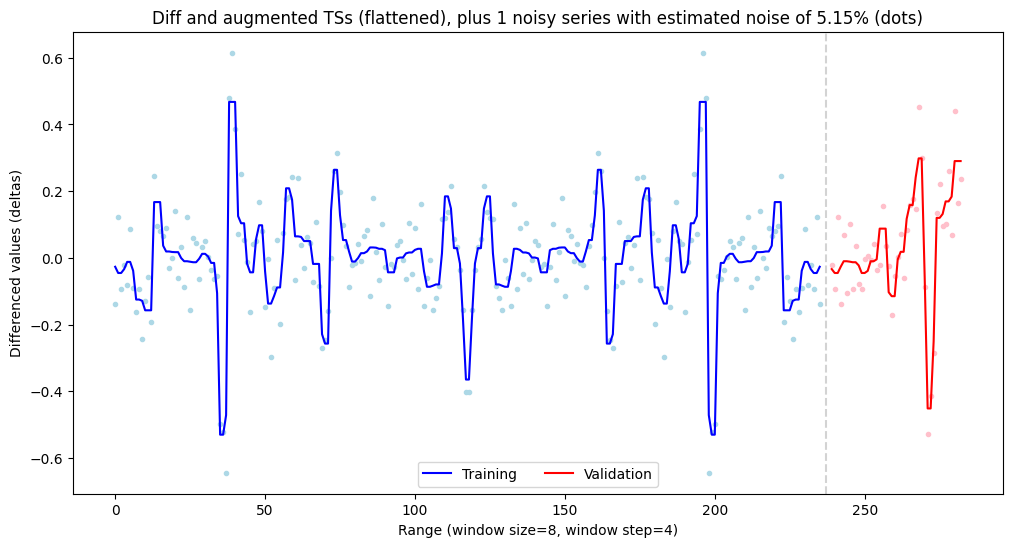

In [11]:
### Create differenced curves - pure and noisy, plus repeated noisy curves

y_train_diff_set = qae_winds_integ_1(qae_wind_to_dict(y_train_enc, 0, wind_step))
y_valid_diff_set = qae_winds_integ_1(qae_wind_to_dict(y_valid_enc, (y_train_enc.shape[0]+2)*wind_step, wind_step))

#train_pure_start = sorted(y_train_diff_set.keys())[0]
train_pure_vals = y_train_diff_set[sorted(y_train_diff_set.keys())[0]]

#valid_pure_start = sorted(y_valid_diff_set.keys())[0]
valid_pure_vals = y_valid_diff_set[sorted(y_valid_diff_set.keys())[0]]

### Generate noisy sets for differenced TSs

y_train_noisy_ts = []; y_valid_noisy_ts = []
y_train_noisy_flats = []; y_valid_noisy_flats = []

### Collect flattened TSs
for ni in range(noise_reps):
    y_train_diff_noisy_set = qae_winds_integ_1(qae_wind_to_dict(y_train_noisy_enc[ni], 0, wind_step))
    y_valid_diff_noisy_set = qae_winds_integ_1(qae_wind_to_dict(y_valid_noisy_enc[ni], (y_train_noisy_enc[ni].shape[0]+2)*wind_step, wind_step))

    train_noisy_vals = np.array(y_train_diff_noisy_set[sorted(y_train_diff_noisy_set.keys())[0]])
    y_train_noisy_flats.append(train_noisy_vals)
    
    valid_noisy_vals = np.array(y_valid_diff_noisy_set[sorted(y_valid_diff_noisy_set.keys())[0]])
    y_valid_noisy_flats.append(valid_noisy_vals)


# Calculate amount of noise in differenced TSs (and last noise)
diff_noise, noise_sum, points_no = calculated_noise(y_train_enc, y_train_noisy_enc[0]) 
print(f'\n\nTS noise = {np.round(noise*100, 2)}%, calculated noise in differenced TS = {np.round(diff_noise*100, 2)}%, '+
      f'total noise = {np.round(noise_sum, 4)}, over the points = {points_no}\n')

# Plot all TS with noise
qae_seq_n_plot(train_pure_vals, valid_pure_vals, y_train_noisy_flats, y_valid_noisy_flats,
               title=f'Diff and augmented TSs (flattened), plus {noise_reps} noisy series with estimated noise of {np.round(diff_noise*100, 2)}% (dots)',
               xlabel=f'Range (window size={wind_size}, window step={wind_step})', ylabel='Differenced values (deltas)',
               save_plot=f'{FIGURES_PATH}/{DATA_PREF}_augm.eps', )

## Building and training a Quantum Autoencoder

In [12]:
### Libraries used in QAE development

import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import ClassicalRegister, QuantumRegister
from qiskit import QuantumCircuit
from qiskit_algorithms.optimizers import COBYLA, NELDER_MEAD, SPSA, ADAM
from qiskit.circuit.library import RealAmplitudes, TwoLocal, ZFeatureMap, ZZFeatureMap
from qiskit.quantum_info import Statevector
from qiskit_algorithms.utils import algorithm_globals
from qiskit.visualization import plot_histogram, plot_state_city, plot_state_paulivec
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit.circuit import Parameter

## Model training

**Sampler** needs to be imported from *qiskit_aer.primitives*.
Unfortunately, *qiskit-aer-gpu 0.12.2* has a bug, which has been fixed 
in the next version *qiskit-aer-gpu 0.13.0*, see notes in the version table.

### Simulator device

In [13]:
### Find what devices are available
from qiskit import Aer
from qiskit_aer.backends import AerSimulator
devices = AerSimulator().available_devices()
devices

('CPU', 'GPU')

In [14]:
## Force the CPU
devices = ('CPU')
devices

'CPU'

### Sampler options

In [15]:
### Create a sampler suitable for the device
#   GPU methods: statevector, tensor_network, density_matrix, unitary

from qiskit.primitives import Sampler # For "CPU", ignores device="GPU" option
from qiskit_aer.primitives import Sampler as AerSampler # For device="GPU" option

seed = 2024

# Use GPU when present, otherwise CPU
if 'GPU' in devices:
    device = 'GPU'
    sampler = AerSampler(
        backend_options={'seed_simulator': seed, 'method': 'statevector', 
                         'device' : device, 'cuStateVec_enable' : True},
        run_options={'seed': seed, 'shots': 1000},
        transpile_options={"seed_transpiler": seed},
    )
else:
    device = 'CPU'
    sampler = Sampler()
    sampler.set_options(method='statevector')
    sampler.set_options(device=device)
    sampler.set_options(seed=seed)
    sampler.options

print(f'Selected device: {device}')

Selected device: CPU


### QAE training parameters

In [16]:
reps=2
ent='sca' # linear, reverse_linear, full, circular, sca, pairwise
num_qubits = wind_size
num_trash = 1
num_latent = num_qubits-num_trash
added_width = 4
shuffle_interv = 20
log_interv = 10
cost_type = 'zeroes' # min1s, swap, zeroes, zerolog
cost_yscale = 'linear' # linear, log
epochs = 2000 
shots=1000
seed=seed

In [17]:
### All created files have the following codes:
#   n: sample size
#   w: window size
#   ws: window step
#   z: level of noise injected
#   zr: replication number of noisy records
TRAIN_PREF = f'{CASE_NAME}_n{samples}_w{wind_size}_ws{wind_step}_z{noise}_zr{noise_reps}_reps{reps}_aw{added_width}_{ent}_lat{num_latent}'
TRAIN_PREF

'beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw4_sca_lat7'

In [18]:
### Training info files 
train_info_default_fpath = f'{TRAIN_PATH}/info.json'
train_info_fpath = f'{TRAIN_PATH}/{TRAIN_PREF}_info.json'
init_fpath = f'{TRAIN_PATH}/{TRAIN_PREF}_init.json'
history_fpath = f'{TRAIN_PATH}/{TRAIN_PREF}_hist{epochs}.json'
params_fpath = f'{PARAMS_PATH}/{TRAIN_PREF}_params.json'
hist_chart_fpath = f'{TRAIN_PATH}/{TRAIN_PREF}_hist{epochs}.eps'
train_info_fpath

'beer_qiskit_v5/training/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw4_sca_lat7_info.json'

In [19]:
## Save training parameters
### Save info details
train_info = \
    {'case_name':CASE_NAME, 
     'major_version':major_version, 
     'minor_version':minor_version,
     'reps':reps,
     'ent':ent, 
     'num_qubits':num_qubits,
     'num_trash':num_trash, 
     'num_latent':num_latent, 
     'added_width':added_width,
     'cost_type':cost_type, 
     'cost_yscale':cost_yscale,
     'shuffle_interv':shuffle_interv,
     'log_interv':log_interv,
     'epochs':epochs,
     'shots':shots,
     'seed':seed}

### Saving the info file
write_json_file(train_info_fpath, train_info)
write_json_file(train_info_default_fpath, train_info)
    
print(f'\nSaved time series info in file "{train_info_fpath}":\n')
for k in train_info.keys():
    print(f'\tinfo[{k}] = {train_info[k]}')
print()


Saved time series info in file "beer_qiskit_v5/training/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw4_sca_lat7_info.json":

	info[case_name] = beer_xdf_2
	info[major_version] = 3
	info[minor_version] = 5
	info[reps] = 2
	info[ent] = sca
	info[num_qubits] = 8
	info[num_trash] = 1
	info[num_latent] = 7
	info[added_width] = 4
	info[cost_type] = zeroes
	info[cost_yscale] = linear
	info[shuffle_interv] = 20
	info[log_interv] = 10
	info[epochs] = 2000
	info[shots] = 1000
	info[seed] = 2024



### Defining structures of training and testing models and their components
*Note that the trainnig model will be used further, however, the testting model is used only as a reference for its structural properties. The actual testing models will be generated dynamically.*

QAE characteristics: 

	training windows=58
	validation windows=10
	inputs=16
	weights=144
	trash layer=1
	latent layer=7
	training qubits=12
	testing qubits=12
	reps=2
	ent=sca
	noise=0.03
	noise repeats=1

	shuffle interv=20
	log interv=10
	cost type=zeroes
	cost yscale=linear
	samples=58
	device=CPU
	epochs=2000
	shots=1000
	seed=2024


Model:



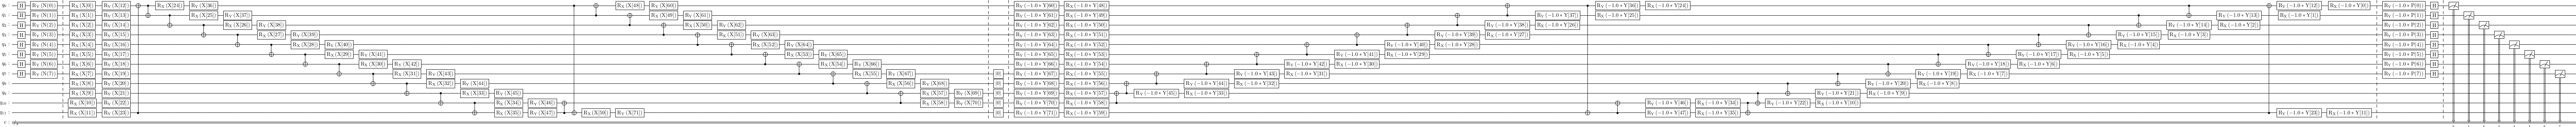

In [20]:
# Models structures

train_qae_qc, in_params, enc_params, dec_params, all_weight_params = \
    train_qae_xyz_xdf(num_latent, num_trash, reps=reps, ent=ent, 
                  in_seq_label='N', in_seq_name='Noisy Input', 
                  out_seq_label='P', out_seq_name='Pure Output',
                  rotation_blocks=['rx', 'ry'], invert_dec=True,
                  added_width=added_width)

noisy_in_params = in_params[:len(in_params)//2]
pure_out_params = in_params[len(in_params)//2:]

train_qae_qc = train_qae_qc.decompose()

# train_qae_qc, pure_out_params, dec_params, noisy_in_params, enc_params = \
#     full_qae_encoder_with_swap(num_latent, num_trash, reps=reps, ent=ent,
#                   pure_seq_name='Pure Input', pure_seq_label='P', 
#                   noisy_seq_name='Noisy Input', noisy_seq_label='N', 
#                   enc_name='Encoder', enc_label='X',
#                   dec_name='Decoder', dec_label='Y')
#
# train_qae_qc = train_qae_qc.decompose()
#
# ### Collect weight parameters
# all_weight_params = []
# for in_p in enc_params:
#     all_weight_params.append(in_p)    
# for out_p in dec_params:
#     all_weight_params.append(out_p)        
#
# ### Collect all input parameters (noisy+pure)
# in_params = []
# for in_p in noisy_in_params:
#     in_params.append(in_p)    
# for out_p in pure_out_params:
#     in_params.append(out_p)        


### Report model details
print(f'QAE characteristics: \n\n'+
      f'\ttraining windows={len(y_train_enc)}\n'+
      f'\tvalidation windows={len(y_valid_enc)}\n'+
      f'\tinputs={len(in_params)}\n'+
      f'\tweights={len(all_weight_params)}\n'+
      f'\ttrash layer={num_trash}\n'+
      f'\tlatent layer={num_latent}\n'+
      f'\ttraining qubits={len(train_qae_qc.qubits)}\n'+
      f'\ttesting qubits={len(train_qae_qc.qubits)}\n'+
      f'\treps={reps}\n'+
      f'\tent={ent}\n'+
      f'\tnoise={noise}\n'+
      f'\tnoise repeats={noise_reps}\n'+
      f'\n'+
      f'\tshuffle interv={shuffle_interv}\n'+
      f'\tlog interv={log_interv}\n'+
      f'\tcost type={cost_type}\n'+
      f'\tcost yscale={cost_yscale}\n'+
      f'\tsamples={y_train_enc.shape[0]}\n'+
      f'\tdevice={device}\n'+
      f'\tepochs={epochs}\n'+
      f'\tshots={shots}\n'+
      f'\tseed={seed}\n'+
      ''
     )

# print(f'\nTraining autoencoder:')
# print(f'\nInput parameters:\n{noisy_in_params}')
# print(f'\nOutput parameters:\n{pure_out_params}')
# print(f'\nEncoder parameters:\n{enc_params}')
# print(f'\nDecoder parameters:\n{dec_params}')
# print(f'\nAll input parameters:\n{in_params}')
# print(f'\nAll training parameters:\n{all_weight_params}')

print('\nModel:\n')
display(train_qae_qc.draw("latex", style="iqp", scale=0.7))
print('')

### Preparing data for full-QAE training

In [21]:
### Preparing data for training
#   - First half of each row is to fill in the noisy input block
#   - Second half of each row is to fill the expected pure output block

# Testing full-QAE with noise, but no separate Decoder
y_train_noisy_and_pure = []
for y_train_noisy_enc_n in y_train_noisy_enc:
    for (y_noisy, y_pure) in zip(y_train_noisy_enc_n, y_train_enc):
        y_train_noisy_and_pure.append(list(y_noisy)+list(y_pure))
y_train_noisy_and_pure = np.array(y_train_noisy_and_pure)

print('\n0th Noisy TS + Pure')
print(f'\nNoisy training data:\n{y_train_noisy_enc[0][0:3]}')
print(f'\nPure training data:\n{y_train_enc[0:3]}')
print(f'\nNoisy+pure training data:\n{y_train_noisy_and_pure[0:3]}\n')

print(f'Training set of {noise_reps}x{y_train_enc.shape[0]}={noise_reps*y_train_enc.shape[0]} records\nInput of noisy+pure data of length {y_train_noisy_and_pure.shape[1]}\n')


0th Noisy TS + Pure

Noisy training data:
[[-0.13865552  0.12348824 -0.09251184 -0.02069989 -0.08273963  0.08756047
  -0.09121654 -0.16214249]
 [-0.08273963  0.08756047 -0.09121654 -0.16214249 -0.09360208 -0.2439032
  -0.1285665  -0.05754037]
 [-0.09360208 -0.2439032  -0.1285665  -0.05754037 -0.19311464  0.24526235
   0.09469878  0.08049064]]

Pure training data:
[[-0.0266739  -0.04534563 -0.04534563 -0.03360911 -0.01209217 -0.01209217
  -0.03864752 -0.1249524 ]
 [-0.01209217 -0.01209217 -0.03864752 -0.1249524  -0.1249524  -0.12874602
  -0.15719818 -0.15719818]
 [-0.1249524  -0.12874602 -0.15719818 -0.15719818 -0.15719818  0.16727499
   0.16727499  0.16727499]]

Noisy+pure training data:
[[-0.13865552  0.12348824 -0.09251184 -0.02069989 -0.08273963  0.08756047
  -0.09121654 -0.16214249 -0.0266739  -0.04534563 -0.04534563 -0.03360911
  -0.01209217 -0.01209217 -0.03864752 -0.1249524 ]
 [-0.08273963  0.08756047 -0.09121654 -0.16214249 -0.09360208 -0.2439032
  -0.1285665  -0.05754037 -0.0

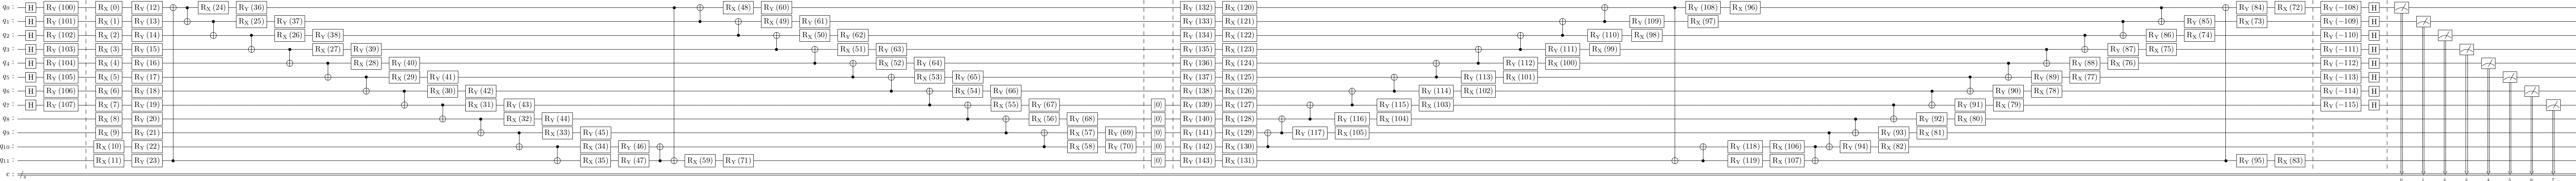

In [22]:
### Testing paramers assignment

p_list = []

p_no = 0
for p in in_params:
    p_list.append(100+p_no)
    p_no += 1

init_pt = range(len(all_weight_params))
p_no = 0
for p in all_weight_params[:len(all_weight_params)//2]:
    p_list.append(init_pt[p_no])
    p_no += 1
for p in all_weight_params[len(all_weight_params)//2:]:
    p_list.append(-init_pt[p_no])
    p_no += 1

qc=train_qae_qc
qc=qc.assign_parameters(p_list)
qc.draw("latex", style="clifford", scale=1, fold=-1) # style=clifford/iqp

### Setting the initial point
Since model training may take a long time we have already pre-trained the model for some iterations and saved the pre-trained weights. We'll continue training from that point by setting `initial_point` to a vector of pre-trained weights.

In [23]:
saved_starting_point = False

if saved_starting_point:
    ### Using previously saved init point
    print(f'Using previously saved init parameters from file "{init_fpath}"')
    initial_point = read_json_file(init_fpath)
else:
    ### Using a random init point
    print(f'Random init parameters to be saved to file "{init_fpath}"')
    initial_point = algorithm_globals.random.random(len(all_weight_params))

Random init parameters to be saved to file "beer_qiskit_v5/training/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw4_sca_lat7_init.json"


### QAE training

In [24]:
### Select a backend

# backend = Aer.get_backend('aer_simulator_statevector')
# backend = Aer.get_backend('aer_simulator')

In [25]:
# noise_model = NoiseModel.from_backend(backend)
backend = AerSimulator(method='statevector')
backend.set_option('device', 'CPU')
backend.set_option('seed_simulator', seed)
backend.set_option('cuStateVec_enable', True)

In [26]:
### Utility

def identity_interpret(x):
    return x

first_only = lambda x: x % 2

In [27]:
### Test

sample_qnn = SamplerQNN(
    circuit=train_qae_qc,
    input_params=in_params,
    weight_params=all_weight_params,
    interpret=identity_interpret,
    output_shape=2**(train_qae_qc.num_qubits-added_width), #2
    sampler=sampler
)

sample_data = y_train_noisy_and_pure[0:5]

start = time.time()
probs = sample_qnn.forward(sample_data, initial_point)
elapsed = time.time() - start
print(f'Forward pass result for SamplerQNN:\n{probs}.  \nShape: {probs.shape}, Time: {elapsed}')
print(f'Cost = 1-P(|0>^n) = {1-np.sum(probs[:, 0]) / sample_data.shape[0]} (to be minimised)')

Forward pass result for SamplerQNN:
[[0.03772436 0.04334061 0.02894014 ... 0.03133624 0.01546245 0.0434456 ]
 [0.04731554 0.048608   0.02325815 ... 0.03581569 0.03004566 0.04625892]
 [0.03608604 0.05580075 0.02585563 ... 0.0204796  0.02584077 0.02376235]
 [0.04340049 0.04338573 0.01285452 ... 0.0144015  0.02469357 0.02887786]
 [0.04911201 0.05489633 0.01334527 ... 0.01388827 0.01698784 0.02377647]].  
Shape: (5, 256), Time: 0.09663105010986328
Cost = 1-P(|0>^n) = 0.9572723121048731 (to be minimised)


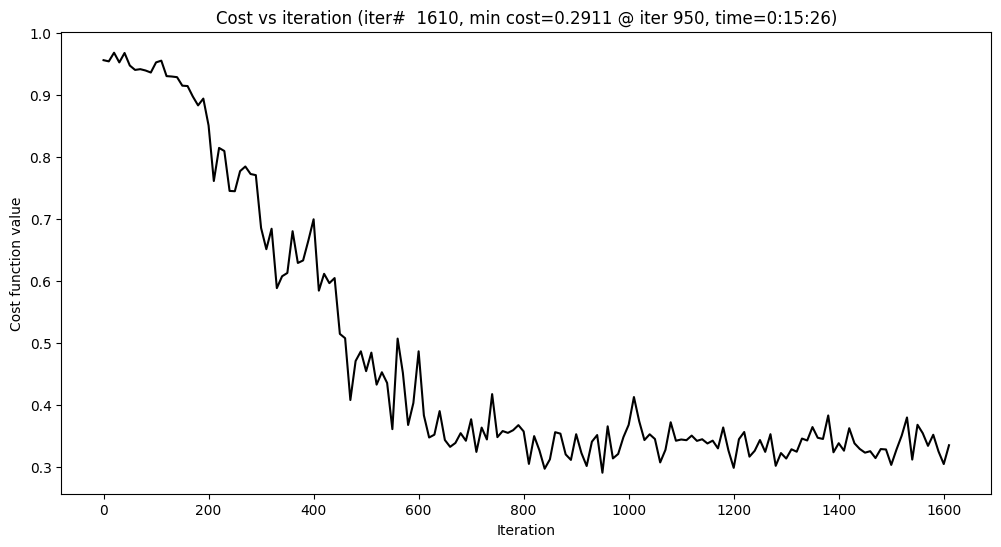

CPU Fit (58 samples, 2 reps, "sca" ent, 7+1 qubits, 144 params, 2000 epochs): 0.36102 min cost, 926.90 sec


In [28]:
training_required = True

if training_required:
    
    print('Training initiated, optimum parameters will be calculated')
    
    qnn = SamplerQNN(
        circuit=train_qae_qc,
        input_params=in_params,
        weight_params=all_weight_params,
        interpret=identity_interpret,
        output_shape=2**(train_qae_qc.num_qubits-added_width), #2
        sampler=sampler
    )

    start = time.time()
    
    opt = COBYLA(maxiter=epochs) # COBYLA, NELDER_MEAD, SPSA
    # opt = SPSA(maxiter=epochs) 

    ### Costs will be tracked and plotted
    cost_func_tswind = Cost(y_train_noisy_and_pure, qnn, opt, initial_point, log_interv=log_interv,
                            shuffle_interv=shuffle_interv, cost_type=cost_type, yscale=cost_yscale)

    ### If testing initialised, MAE will be plotted as well
    # cost_func_tswind.init_testing(y_train_enc, y_valid_enc, y_train_noisy_enc, y_valid_noisy_enc,
    #         num_latent=num_latent, num_trash=num_trash, reps=reps, ent=ent, sample=15,
    #         backend=backend, shots=shots)
    
    opt_result = cost_func_tswind.optimize()
    optimum_parameters = opt_result.x
    minimum_cost = opt_result.fun
    elapsed = time.time() - start

    # Print run statistics
    print(f'{device} Fit ('+
          f'{y_train_noisy_and_pure.shape[0]} samples, '+
          f'{reps} reps, '+
          f'"{ent}" ent, '+
          f'{num_latent}+{num_trash} qubits, '+
          f'{len(all_weight_params)} params, '+
          f'{epochs} epochs): '+
          f'{round(minimum_cost, 5)} min cost, '+
          f'{elapsed:0.2f} sec')

elif saved_starting_point:
    optimum_parameters = initial_point
    print('Training skipped, previously saved optimum parameters will be used here')
else:
    optimum_parameters = initial_point
    print('Training skipped, optimum parameters were generated randomly')    

shots=1:      CPU Fit (58 samples, 2 reps, "linear" ent, 7+1 qubits, 96 params, 2000 epochs): 0.12795 min cost, 340.50 sec<br/>
shots=10:     CPU Fit (58 samples, 2 reps, "linear" ent, 7+1 qubits, 96 params, 1000 epochs): 0.33898 min cost, 280.18 sec<br/>
shots=100:    CPU Fit (58 samples, 2 reps, "linear" ent, 7+1 qubits, 96 params, 1000 epochs): 0.87636 min cost, 243.16 sec<br/>
shots=1000:   CPU Fit (58 samples, 2 reps, "linear" ent, 7+1 qubits, 96 params, 2000 epochs): 0.05051 min cost, 601.48 sec<br/>
shots=1000:   CPU Fit (58 samples, 2 reps, "linear" ent, 7+1 qubits, 96 params, 2000 epochs): 0.05184 min cost, 592.76 sec<br/>
shots=10000:  CPU Fit (58 samples, 2 reps, "linear" ent, 7+1 qubits, 96 params, 2000 epochs): 0.11094 min cost, 399.21 sec<br/>
shots=10000:  CPU Fit (58 samples, 2 reps, "linear" ent, 7+1 qubits, 96 params, 2000 epochs): 0.57737 min cost, 248.35 sec<br/>
shots=100000: CPU Fit (58 samples, 2 reps, "linear" ent, 7+1 qubits, 96 params, 2000 epochs): 0.05430 min cost, 596.68 sec<br/>

## Model testing
Note that all components of a test circuit will be built in the testing process

### Saving the starting point and calculated results

In [29]:
print(f'Files to be saved (when True)\n')
print(f'Optimisation init point: {init_fpath}')
print(f'Optimisation parameters: {params_fpath}')
print(f'History of Cost:         {history_fpath}')
print()

Files to be saved (when True)

Optimisation init point: beer_qiskit_v5/training/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw4_sca_lat7_init.json
Optimisation parameters: beer_qiskit_v5/params/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw4_sca_lat7_params.json
History of Cost:         beer_qiskit_v5/training/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw4_sca_lat7_hist2000.json



In [30]:
### Save the initial point, also save the history file
to_be_saved_starting_point = True

print()
if to_be_saved_starting_point:
    ## Saving the initialisation point
    write_json_file(f'{init_fpath}', opt_result.x.tolist())
    print(f'Saved optimum parameters as the future starting point in:\n\t{init_fpath}')

    ## Saving all optimisation params
    write_json_file(f'{params_fpath}', [list(a) for a in cost_func_tswind.params])
    print(f'Saved all optimisation parameters in:\n\t{params_fpath}')

    ### Saving the history file
    write_json_file(f'{history_fpath}', cost_func_tswind.objective_func_vals)
    print(f'Saved optimisation history in:\n\t{history_fpath}')

else:
    print(f'Parameters and history not saved') 
print()


Saved optimum parameters as the future starting point in:
	beer_qiskit_v5/training/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw4_sca_lat7_init.json
Saved all optimisation parameters in:
	beer_qiskit_v5/params/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw4_sca_lat7_params.json
Saved optimisation history in:
	beer_qiskit_v5/training/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw4_sca_lat7_hist2000.json



## References

1. A wikipedia page on Autoencoder: https://en.wikipedia.org/wiki/Autoencoder

2. Romero, Jonathan, Jonathan P. Olson, and Alan Aspuru-Guzik. "Quantum autoencoders for efficient compression of quantum data." Quantum Science and Technology 2.4 (2017): 045001.

3. Swap Test Algorithm: https://en.wikipedia.org/wiki/Swap_test

4. Bravo-Prieto, Carlos, "Quantum autoencoders with enhanced data encoding." Machine Learning: Science and Technology, 2, May 2021

# Software in use

In [31]:
!pip list | grep -E 'qiskit|torch'

qiskit                        0.45.2
qiskit-aer-gpu                0.13.2
qiskit-algorithms             0.2.2
qiskit-dynamics               0.4.3
qiskit-finance                0.4.0
qiskit-ibm-provider           0.6.3
qiskit-ibm-runtime            0.11.3
qiskit-ibmq-provider          0.20.2
qiskit-machine-learning       0.7.1
qiskit-nature                 0.7.1
qiskit-optimization           0.6.0
qiskit-qasm3-import           0.4.1
qiskit-sphinx-theme           1.12.1
qiskit-terra                  0.45.2
torch                         2.1.0
torchaudio                    2.1.0
torchsummary                  1.5.1
torchvision                   0.16.0
torchviz                      0.0.2
